In [662]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn import metrics
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
import statsmodels.api as sm

In [663]:
df = pd.read_csv("HAI.csv")


In [664]:
print(df.head())


  Unnamed: 0  Acute Care SIR  Critical Access SIR
0     CLABSI           0.724                0.736
1      CAUTI           0.621                0.576
2        VAE           1.131                1.417
3        SSI           0.965                0.894


In [665]:
categories = ['CLABSI', 'CAUTI', 'VAE', 'SSI']
values = [0.724, 0.621, 1.131, 0.965]

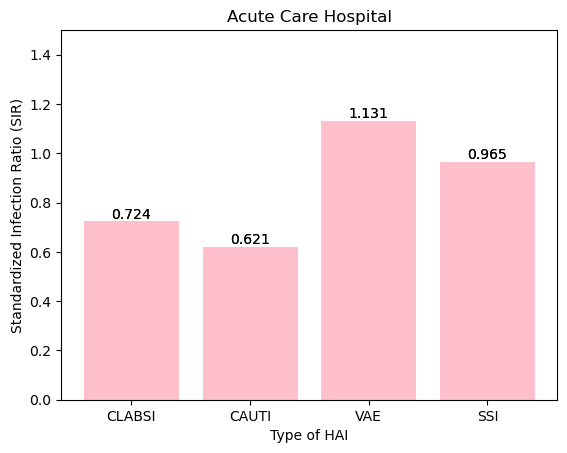

In [666]:
plt.bar(categories, values, color ='pink')
for i in range(len(categories)):
    plt.text(i, values[i], str(values[i]), ha='center', va='bottom')
ax = plt.gca()
bars = ax.bar(categories, values, color='pink')
ax.bar_label(bars)
plt.xlabel("Type of HAI")
plt.ylabel("Standardized Infection Ratio (SIR)")
plt.title("Acute Care Hospital")
plt.ylim(0, 1.5)
plt.show()

In [667]:
categories = ['CLABSI', 'CAUTI', 'VAE', 'SSI']
values2 = [0.736, 0.576, 1.417, 0.894]

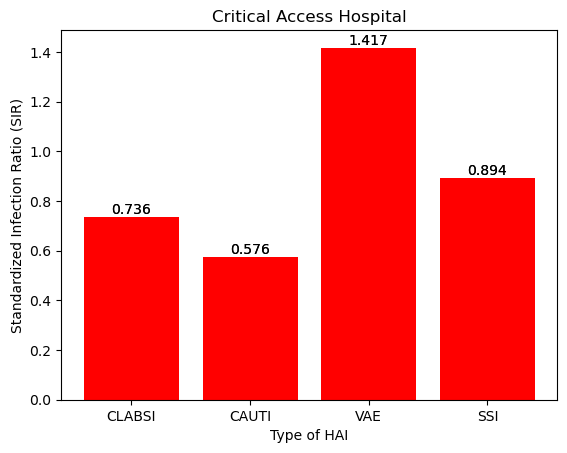

In [668]:
plt.bar(categories, values2, color = 'red')
for i in range(len(categories)):
    plt.text(i, values2[i], str(values2[i]), ha='center', va='bottom')
ax = plt.gca()
bars = ax.bar(categories, values2, color='red')
ax.bar_label(bars)
plt.xlabel("Type of HAI")
plt.ylabel("Standardized Infection Ratio (SIR)")
plt.title("Critical Access Hospital")
plt.show()

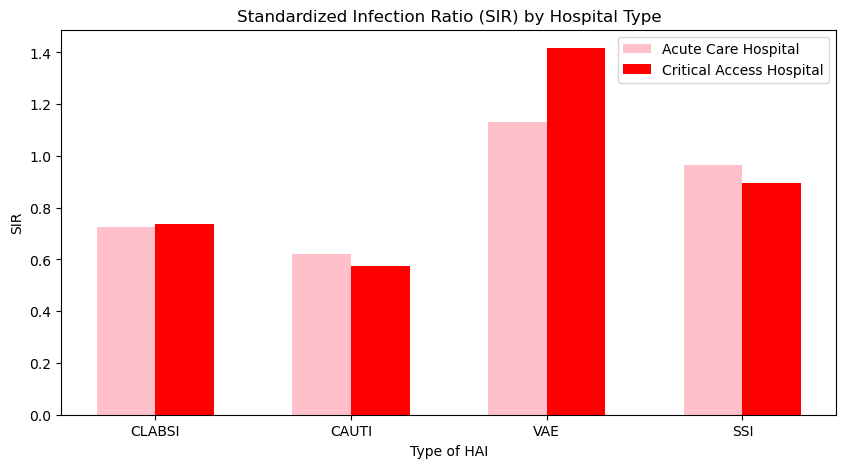

In [669]:
N = 4

bar_1 = [0.724, 0.621, 1.131, 0.965]
bar_2 = [0.736, 0.576, 1.417, 0.894]

ind = np.arange(N)

plt.figure(figsize=(10,5))

width = 0.3

plt.bar(ind, bar_1, width, label='Acute Care Hospital', color='pink')
plt.bar(ind + width, bar_2, width, label = 'Critical Access Hospital', color = 'red')

plt.xlabel('Type of HAI')
plt.ylabel('SIR')
plt.title('Standardized Infection Ratio (SIR) by Hospital Type')

plt.xticks(ind + width / 2, ('CLABSI', 'CAUTI', 'VAE', 'SSI'))
plt.legend(loc='best')
plt.show()

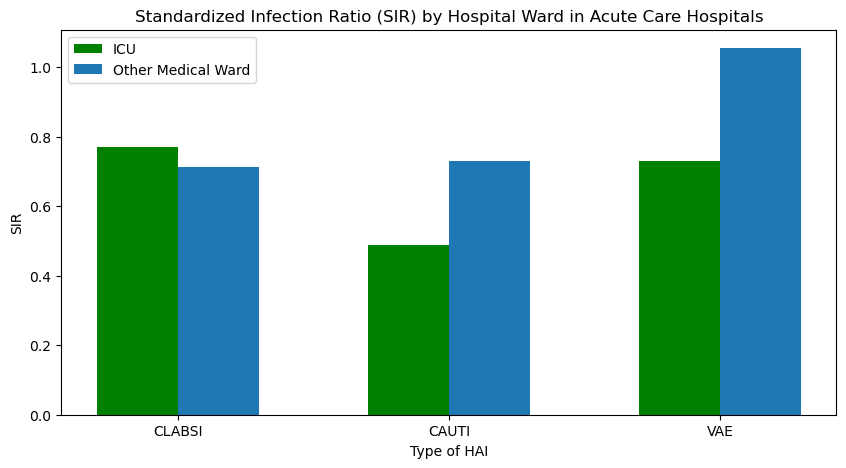

In [670]:
N = 3

bar_3 = [0.769, 0.488, 0.730]
bar_4 = [0.712, 0.730, 1.055]

ind = np.arange(N)

plt.figure(figsize=(10,5))

width = 0.3

plt.bar(ind, bar_3, width, label='ICU', color='green')
plt.bar(ind + width, bar_4, width, label = 'Other Medical Ward')

plt.xlabel('Type of HAI')
plt.ylabel('SIR')
plt.title('Standardized Infection Ratio (SIR) by Hospital Ward in Acute Care Hospitals')

plt.xticks(ind + width / 2, ('CLABSI', 'CAUTI', 'VAE'))
plt.legend(loc='best')
plt.show()

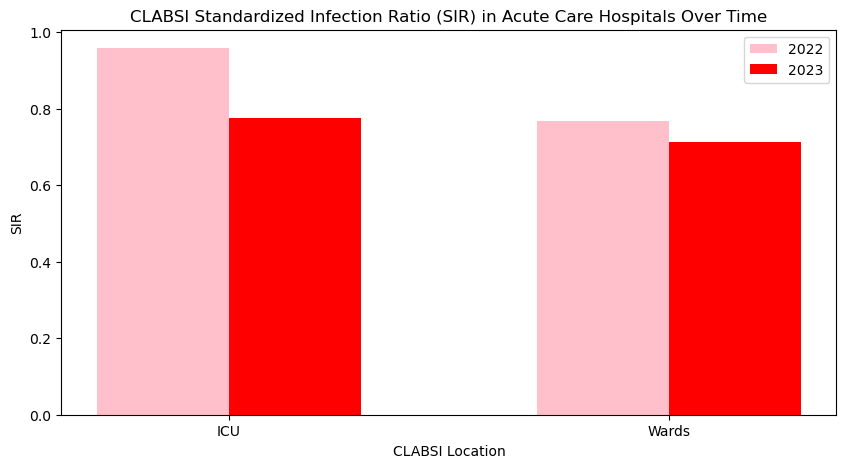

In [671]:
N = 2

bar_1 = [0.959, 0.769]
bar_2 = [0.775, 0.712]

ind = np.arange(N)

plt.figure(figsize=(10,5))

width = 0.3

plt.bar(ind, bar_1, width, label='2022', color='pink')
plt.bar(ind + width, bar_2, width, label = '2023', color = 'red')

plt.xlabel('CLABSI Location')
plt.ylabel('SIR')
plt.title('CLABSI Standardized Infection Ratio (SIR) in Acute Care Hospitals Over Time')

plt.xticks(ind + width / 2, ('ICU', 'Wards'))
plt.legend(loc='best')
plt.show()

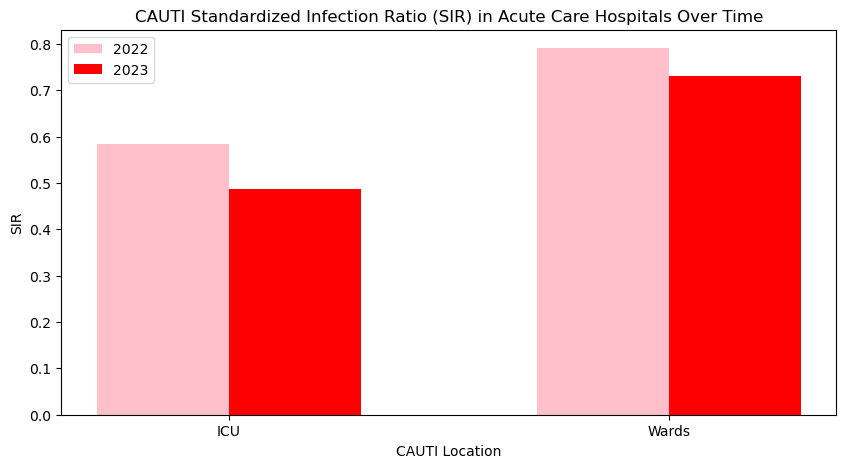

In [672]:
N = 2

bar_1 = [0.584, 0.791]
bar_2 = [0.488, 0.730]

ind = np.arange(N)

plt.figure(figsize=(10,5))

width = 0.3

plt.bar(ind, bar_1, width, label='2022', color='pink')
plt.bar(ind + width, bar_2, width, label = '2023', color = 'red')

plt.xlabel('CAUTI Location')
plt.ylabel('SIR')
plt.title('CAUTI Standardized Infection Ratio (SIR) in Acute Care Hospitals Over Time')

plt.xticks(ind + width / 2, ('ICU', 'Wards'))
plt.legend(loc='best')
plt.show()

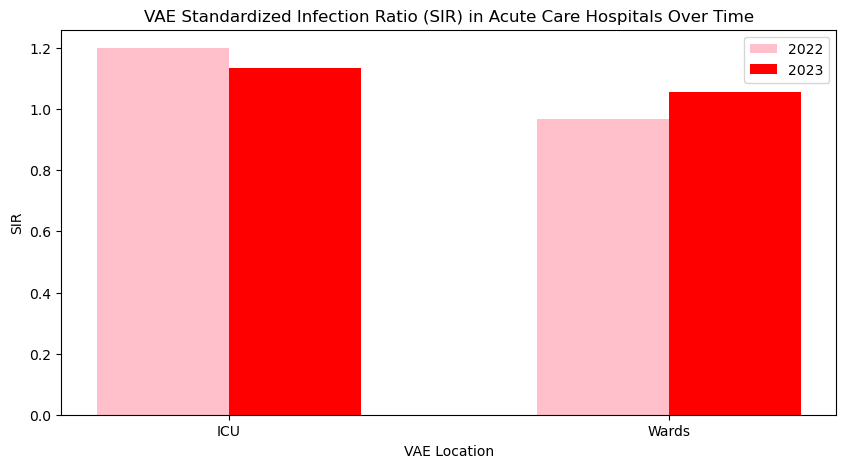

In [673]:
N = 2

bar_1 = [1.200, 0.968]
bar_2 = [1.135, 1.055]

ind = np.arange(N)

plt.figure(figsize=(10,5))

width = 0.3

plt.bar(ind, bar_1, width, label='2022', color='pink')
plt.bar(ind + width, bar_2, width, label = '2023', color = 'red')

plt.xlabel('VAE Location')
plt.ylabel('SIR')
plt.title('VAE Standardized Infection Ratio (SIR) in Acute Care Hospitals Over Time')

plt.xticks(ind + width / 2, ('ICU', 'Wards'))
plt.legend(loc='best')
plt.show()

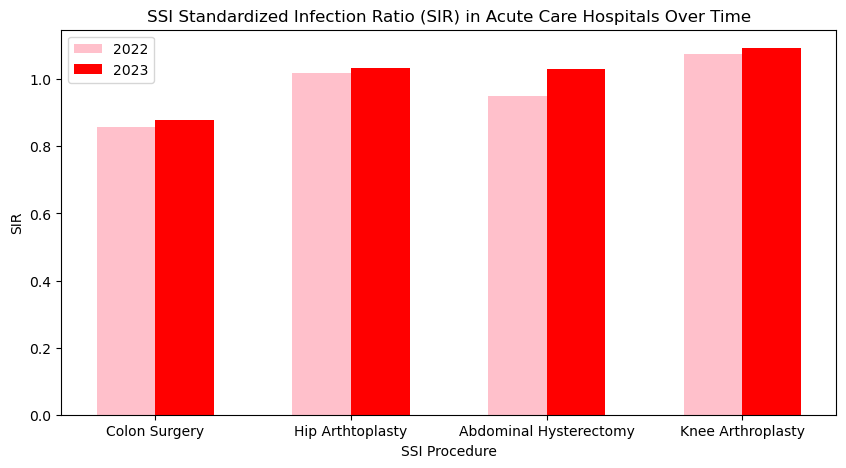

In [674]:
N = 4

bar_1 = [0.858, 1.019, 0.951, 1.074]
bar_2 = [0.879, 1.033, 1.031, 1.093]

ind = np.arange(N)

plt.figure(figsize=(10,5))

width = 0.3

plt.bar(ind, bar_1, width, label='2022', color='pink')
plt.bar(ind + width, bar_2, width, label = '2023', color = 'red')

plt.xlabel('SSI Procedure')
plt.ylabel('SIR')
plt.title('SSI Standardized Infection Ratio (SIR) in Acute Care Hospitals Over Time')

plt.xticks(ind + width / 2, ('Colon Surgery', 'Hip Arthtoplasty', 'Abdominal Hysterectomy', 'Knee Arthroplasty'))
plt.legend(loc='best')
plt.show()

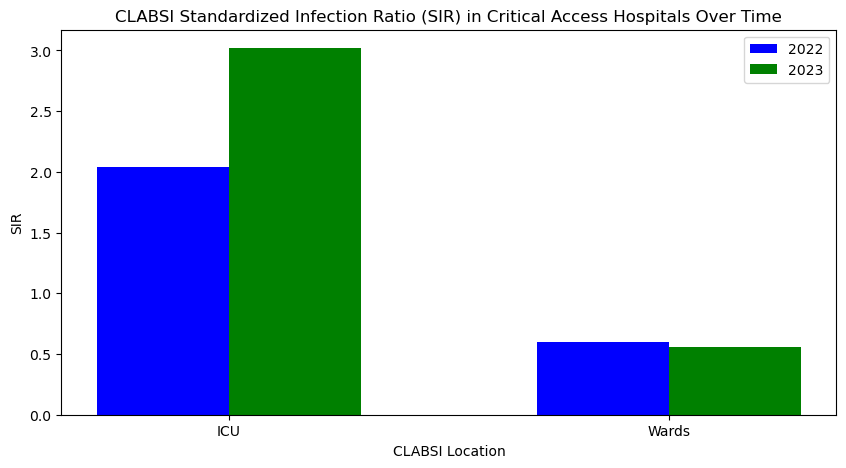

In [675]:
N = 2

bar_1 = [2.041, 0.602]
bar_2 = [3.020, 0.558]

ind = np.arange(N)

plt.figure(figsize=(10,5))

width = 0.3

plt.bar(ind, bar_1, width, label='2022', color='blue')
plt.bar(ind + width, bar_2, width, label = '2023', color = 'green')

plt.xlabel('CLABSI Location')
plt.ylabel('SIR')
plt.title('CLABSI Standardized Infection Ratio (SIR) in Critical Access Hospitals Over Time')

plt.xticks(ind + width / 2, ('ICU', 'Wards'))
plt.legend(loc='best')
plt.show()

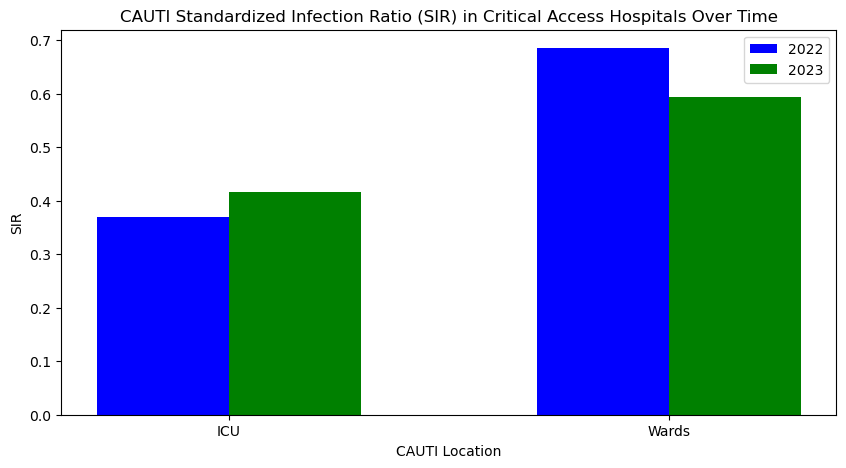

In [676]:
N = 2

bar_1 = [0.370, 0.685]
bar_2 = [0.417, 0.593]

ind = np.arange(N)

plt.figure(figsize=(10,5))

width = 0.3

plt.bar(ind, bar_1, width, label='2022', color='blue')
plt.bar(ind + width, bar_2, width, label = '2023', color = 'green')

plt.xlabel('CAUTI Location')
plt.ylabel('SIR')
plt.title('CAUTI Standardized Infection Ratio (SIR) in Critical Access Hospitals Over Time')

plt.xticks(ind + width / 2, ('ICU', 'Wards'))
plt.legend(loc='best')
plt.show()

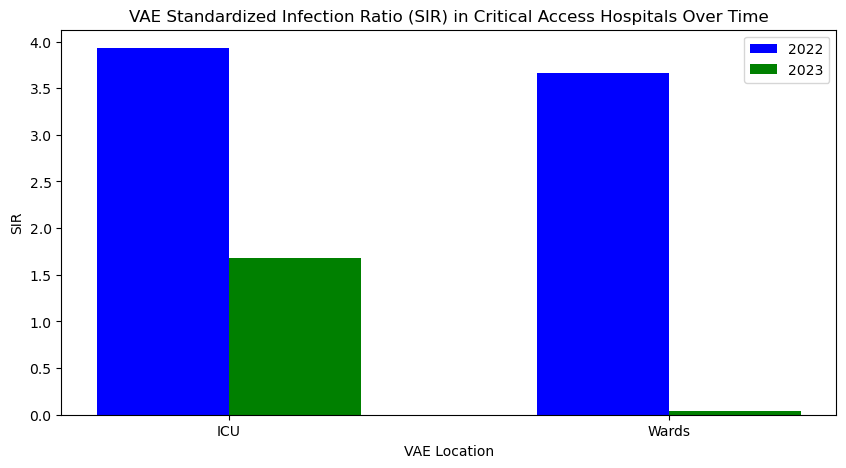

In [677]:
N = 2

bar_1 = [3.930, 3.664]
bar_2 = [1.681, 0.04]

ind = np.arange(N)

plt.figure(figsize=(10,5))

width = 0.3

plt.bar(ind, bar_1, width, label='2022', color='blue')
plt.bar(ind + width, bar_2, width, label = '2023', color = 'green')

plt.xlabel('VAE Location')
plt.ylabel('SIR')
plt.title('VAE Standardized Infection Ratio (SIR) in Critical Access Hospitals Over Time')

plt.xticks(ind + width / 2, ('ICU', 'Wards'))
plt.legend(loc='best')
plt.show()

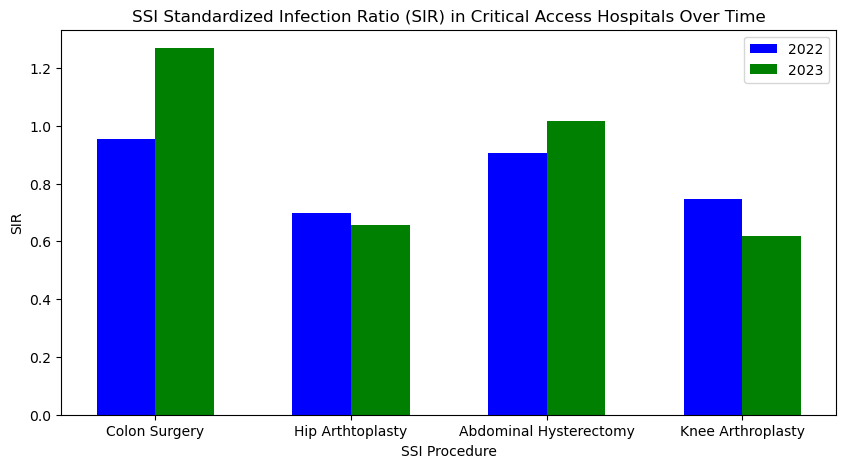

In [678]:
N = 4

bar_1 = [0.953, 0.697, 0.907, 0.748]
bar_2 = [1.269, 0.658, 1.018, 0.619]

ind = np.arange(N)

plt.figure(figsize=(10,5))

width = 0.3

plt.bar(ind, bar_1, width, label='2022', color='blue')
plt.bar(ind + width, bar_2, width, label = '2023', color = 'green')

plt.xlabel('SSI Procedure')
plt.ylabel('SIR')
plt.title('SSI Standardized Infection Ratio (SIR) in Critical Access Hospitals Over Time')

plt.xticks(ind + width / 2, ('Colon Surgery', 'Hip Arthtoplasty', 'Abdominal Hysterectomy', 'Knee Arthroplasty'))
plt.legend(loc='best')
plt.show()

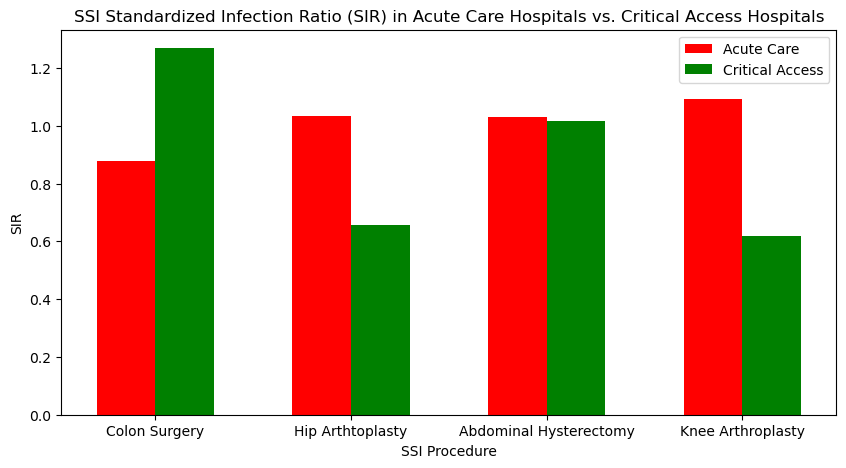

In [679]:
N = 4

bar_1 = [0.879, 1.033, 1.031, 1.093]
bar_2 = [1.269, 0.658, 1.018, 0.619]

ind = np.arange(N)

plt.figure(figsize=(10,5))

width = 0.3

plt.bar(ind, bar_1, width, label='Acute Care', color='red')
plt.bar(ind + width, bar_2, width, label = 'Critical Access', color = 'green')

plt.xlabel('SSI Procedure')
plt.ylabel('SIR')
plt.title('SSI Standardized Infection Ratio (SIR) in Acute Care Hospitals vs. Critical Access Hospitals')

plt.xticks(ind + width / 2, ('Colon Surgery', 'Hip Arthtoplasty', 'Abdominal Hysterectomy', 'Knee Arthroplasty'))
plt.legend(loc='best')
plt.show()

In [680]:
df = pd.read_csv("Hospital_Data.csv")

In [681]:
print(df.head())

  Hospital_Type    SIR
0         Acute  0.919
1         Acute  0.512
2         Acute  0.677
3         Acute  0.667
4         Acute  0.751


<Axes: xlabel='Hospital_Type', ylabel='SIR'>

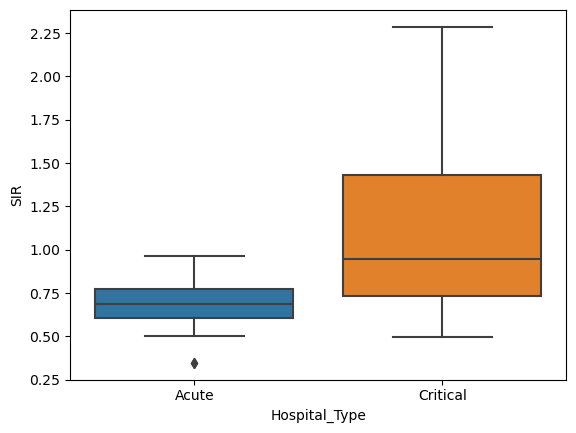

In [682]:
sns.boxplot(y='SIR',x='Hospital_Type',data=df)

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


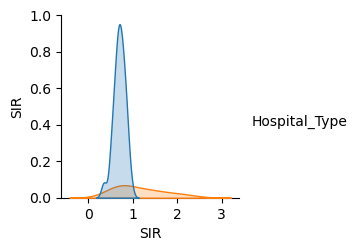

In [683]:
X = df[['Hospital_Type']]
X = pd.get_dummies(data=X, drop_first=True)
X.head()
sns.pairplot(df,hue='Hospital_Type')

In [684]:
Y = df['SIR']

In [685]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=101)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(59, 1)
(15, 1)
(59,)
(15,)


In [686]:
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [687]:
print(model.intercept_)

0.7179999999999997


In [688]:
coeff_parameter = pd.DataFrame(model.coef_,X.columns,columns=['Coefficient'])
coeff_parameter

,Coefficient
Hospital_Type_Critical,0.409813


In [689]:
predictions = model.predict(X_test)
predictions

array([0.718    , 0.718    , 0.718    , 0.718    , 1.1278125, 0.718    ,
       0.718    , 0.718    , 0.718    , 0.718    , 0.718    , 0.718    ,
       0.718    , 0.718    , 0.718    ])

<Axes: xlabel='SIR'>

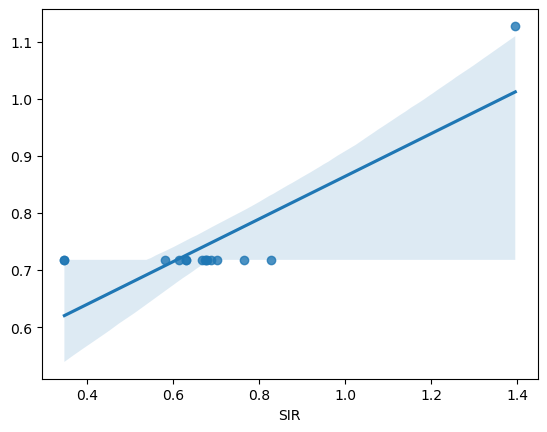

In [690]:
sns.regplot(x=y_test, y=predictions)

In [691]:
X_train_Sm= sm.add_constant(X_train)
X_train_Sm= sm.add_constant(X_train)
ls=sm.OLS(y_train,X_train_Sm.astype(float)).fit()
print(ls.summary())

                            OLS Regression Results                            
Dep. Variable:                    SIR   R-squared:                       0.274
Model:                            OLS   Adj. R-squared:                  0.261
Method:                 Least Squares   F-statistic:                     21.48
Date:                Sun, 20 Apr 2025   Prob (F-statistic):           2.13e-05
Time:                        23:28:36   Log-Likelihood:                -12.048
No. Observations:                  59   AIC:                             28.10
Df Residuals:                      57   BIC:                             32.25
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      0

In [692]:
categorical_features = ['Hospital_Type']
df = pd.get_dummies(df, columns=categorical_features, drop_first=True)
print(df.head())

     SIR  Hospital_Type_Critical
0  0.919                   False
1  0.512                   False
2  0.677                   False
3  0.667                   False
4  0.751                   False


In [693]:
df.corr()

,SIR,Hospital_Type_Critical
SIR,1.000000,0.564973
Hospital_Type_Critical,0.564973,1.000000


<Axes: >

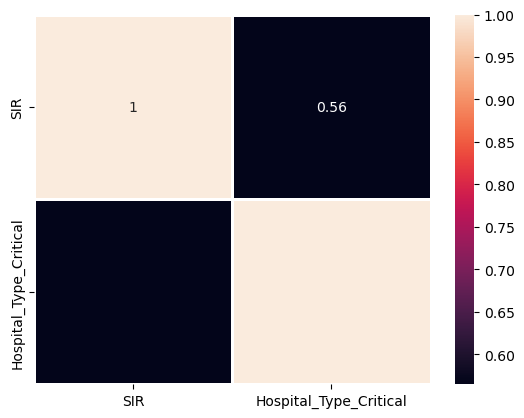

In [694]:
sns.heatmap(df.corr(),annot=True,lw=1)

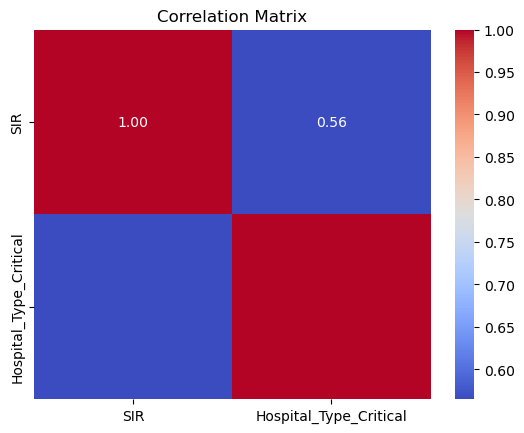

In [695]:
corr_matrix = df.corr(method='pearson')
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f") 
plt.title('Correlation Matrix')
plt.show()